In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
import subprocess; print(subprocess.check_output(['nvidia-smi']).decode('utf-8'))

Sat Apr 18 13:29:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-PCIE-40GB          On  |   00000000:37:00.0 Off |                    0 |
| N/A   66C    P0             46W /  250W |    1191MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

# Load Dataset

In [3]:
class FeatureDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, processor):
        self.base_dataset = base_dataset
        self.processor = processor

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]  # assuming PIL image
        processed = self.processor(images=img, return_tensors="pt")
        pixel_values = processed["pixel_values"].squeeze(0)
        return pixel_values, label

In [12]:
import random
from torch.utils.data import Subset
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_dir = "./imagenet_validation"      # Download from https://www.kaggle.com/datasets/tusonggao/imagenet-validation-dataset

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    # transforms.CenterCrop(256),
    transforms.ToTensor(),
])

dataset_base = datasets.ImageFolder(root=data_dir, transform=transform)

n_samples = 50
indices = random.sample(range(len(dataset_base)), n_samples)
subset = Subset(dataset_base, indices)

def get_affine_dataset(processor, translation=None, rotation=0, scale=None, shear=None):
    transform_affine = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomAffine(degrees=rotation, translate=translation, scale=scale, shear=shear),
        transforms.ToTensor(),
    ])

    dataset_affine = datasets.ImageFolder(root=data_dir, transform=transform_affine)
    subset_affine = Subset(dataset_affine, indices)

    feature_affine = FeatureDataset(subset_affine, processor)

    return DataLoader(
        feature_affine,
        batch_size=32,
        shuffle=False,
        num_workers=4,
    )

num_classes = len(dataset_base.classes)
print("Classes:", num_classes)

Classes: 1000


# Utils

In [5]:
import torch
import gc


def clear_gpu_memory():
    # 1. Delete model and optimizer variables if they exist
    # You might need to manually 'del model' and 'del optimizer'
    # before calling this if they are in the global scope.

    # 2. Trigger Python's garbage collector
    gc.collect()

    # 3. Clear the PyTorch CUDA cache
    torch.cuda.empty_cache()

    # 4. (Optional) If you are using DistributedDataParallel or similar
    # it helps to reset the peak memory stats
    torch.cuda.reset_peak_memory_stats()

    print("GPU memory cleared.")

In [6]:
import pickle
import os


results_dir = "./cka_results/"
os.makedirs(results_dir, exist_ok=True)


def save_to_pickle(cka_results, name_a, name_b):
    with open(results_dir + f'cka_results_{name_a}_{name_b}.pkl', 'wb') as f:
        pickle.dump(cka_results, f)

def load_from_pickle(name_a, name_b):
    with open(results_dir + f'cka_results_{name_a}_{name_b}.pkl', 'rb') as f:
        cka_results = pickle.load(f)

    return cka_results

# CKA

In [7]:
from torch_cka import CKA
import matplotlib.pyplot as plt
import seaborn as sns


def plot_cka_matrix(results, save=True):
    # Extract the CKA values and layer names
    # results['CKA'] is the actual similarity matrix
    cka_matrix = results['CKA']
    model1_layers = results['model1_layers']
    model2_layers = results['model2_layers']

    # 2. Set up the plotting environment
    plt.figure(figsize=(10, 8))

    # 3. Create the heatmap
    # We use 'magma' or 'viridis' for high contrast
    ax = sns.heatmap(
        cka_matrix,
        annot=False,
        fmt=".2f",
        cmap='magma',
        xticklabels=model2_layers,
        yticklabels=model1_layers,
        vmin=0.0,  # Forces the bottom of the legend to 0
        vmax=1.0   # Forces the top of the legend to 1
    )
    ax.invert_yaxis()

    # 4. Add labels and formatting
    plt.title("CKA Similarity Matrix", fontsize=15)
    plt.xlabel(f"Layers: {results['model2_name']}", fontsize=12)
    plt.ylabel(f"Layers: {results['model1_name']}", fontsize=12)

    # Rotate labels if there are many layers to prevent overlapping
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    plt.tight_layout()

    if save:
        plt.savefig(results_dir + f"cka_similarity_{results['model1_name']}_vs_{results['model2_name']}.png", dpi=300)

    plt.show()

### CLIP Base

In [10]:
class CLIPVisionWrapper(torch.nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        self.model = clip_model.vision_model

    def forward(self, x):
        out = self.model(pixel_values=x)
        return out.pooler_output

In [ ]:
from transformers import CLIPModel, CLIPProcessor


clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch16")
model = CLIPVisionWrapper(clip)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch16")
loader = get_affine_dataset(processor)

available_layers = [name for name, _ in model.named_modules()]
# print("Available layers in the model:")
# for layer in available_layers:
#     print(layer)

del clip
del model
clear_gpu_memory()

layers_to_compare = ["model.embeddings.patch_embedding"]
layers_to_compare += [f"model.encoder.layers.{i}" for i in range(12)]
layers_to_compare += ["model.post_layernorm"]
layers_to_compare

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPU memory cleared.


['model.embeddings.patch_embedding',
 'model.encoder.layers.0',
 'model.encoder.layers.1',
 'model.encoder.layers.2',
 'model.encoder.layers.3',
 'model.encoder.layers.4',
 'model.encoder.layers.5',
 'model.encoder.layers.6',
 'model.encoder.layers.7',
 'model.encoder.layers.8',
 'model.encoder.layers.9',
 'model.encoder.layers.10',
 'model.encoder.layers.11',
 'model.post_layernorm']

##### Baseline

In [ ]:
model_1_name = "CLIP Base"
model_2_name = "CLIP Base"

clip_1 = CLIPModel.from_pretrained("openai/clip-vit-base-patch16").to(device)
clip_2 = CLIPModel.from_pretrained("openai/clip-vit-base-patch16").to(device)

model_1 = CLIPVisionWrapper(clip_1)
model_2 = CLIPVisionWrapper(clip_2)

cka = CKA(
    model_1,
    model_2,
    model1_name=model_1_name,
    model2_name=model_2_name,
    model1_layers=layers_to_compare,
    model2_layers=layers_to_compare,
    device=device,
)

loader_affine = get_affine_dataset(processor)
cka.compare(loader, loader_affine, NaN_fix=True)
results = cka.export()

save_to_pickle(results, model_1_name, model_2_name)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/dtu/3d-imaging-center/courses/02518/groups/members/Eric_s257372/ADLCV_Project/.venv/lib/python3.11/site-packages/torch_cka/cka.py:53: UserWarning: Both model have identical names - CLIP Base. It may cause confusion when interpreting the results. Consider giving unique names to the models :)
  warn(
| Comparing features |:   0%|                                                                     | 0/2 [00:00<?, ?it/s]

Forward ran
Forward ran


| Comparing features |:  50%|██████████████████████████████▌                              | 1/2 [00:01<00:01,  1.90s/it]

Forward ran
Forward ran


| Comparing features |: 100%|█████████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.14s/it]


In [ ]:
del clip_1
del clip_2
del model_1
del model_2
del cka
clear_gpu_memory()

GPU memory cleared.


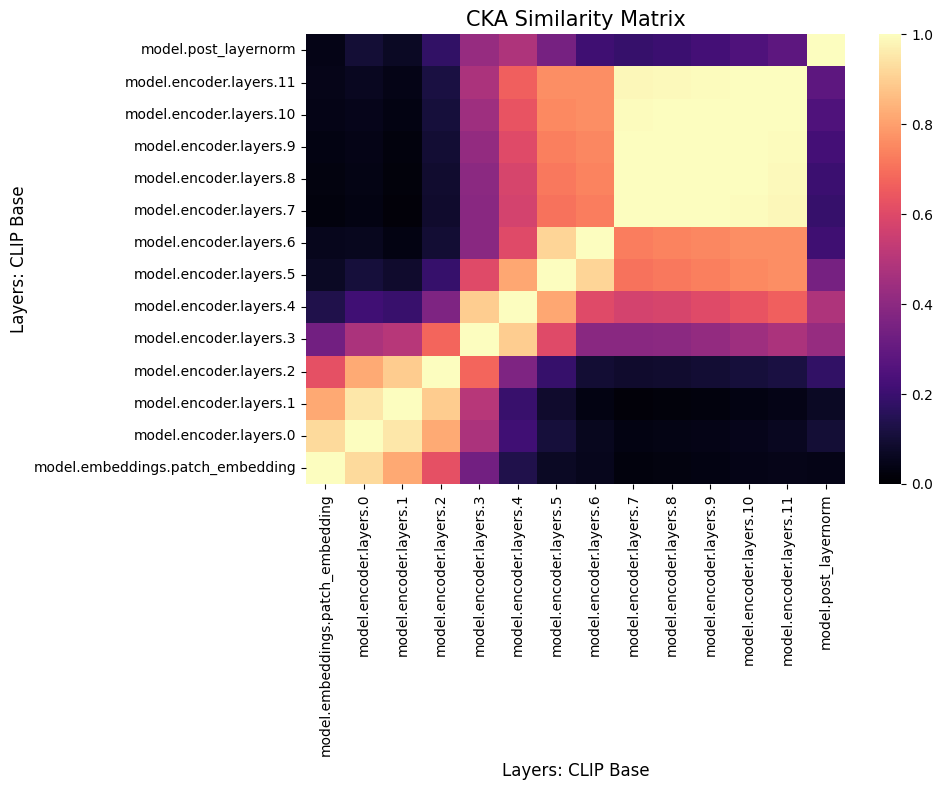

In [12]:
model_1_name = "CLIP Base"
model_2_name = "CLIP Base"

results = load_from_pickle(model_1_name, model_2_name)

plot_cka_matrix(results)

In [14]:
clear_gpu_memory()

GPU memory cleared.


##### Rotate 90

In [ ]:
model_1_name = "CLIP Base"
model_2_name = "CLIP Base Rotated 90º"

clip_1 = CLIPModel.from_pretrained("openai/clip-vit-base-patch16").to(device)
clip_2 = CLIPModel.from_pretrained("openai/clip-vit-base-patch16").to(device)

model_1 = CLIPVisionWrapper(clip_1)
model_2 = CLIPVisionWrapper(clip_2)

cka = CKA(
    model_1,
    model_2,
    model1_name=model_1_name,
    model2_name=model_2_name,
    model1_layers=layers_to_compare,
    model2_layers=layers_to_compare,
    device=device,
)

loader_affine = get_affine_dataset(processor, rotation=(-90, -90))
cka.compare(loader, loader_affine, NaN_fix=True)
results = cka.export()

save_to_pickle(results, model_1_name, model_2_name)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
| Comparing features |:   0%|                                                                     | 0/2 [00:00<?, ?it/s]

Forward ran
Forward ran


| Comparing features |:  50%|██████████████████████████████▌                              | 1/2 [00:02<00:02,  2.02s/it]

Forward ran
Forward ran


| Comparing features |: 100%|█████████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.20s/it]


In [ ]:
del clip_1
del clip_2
del model_1
del model_2
del cka
clear_gpu_memory()

GPU memory cleared.


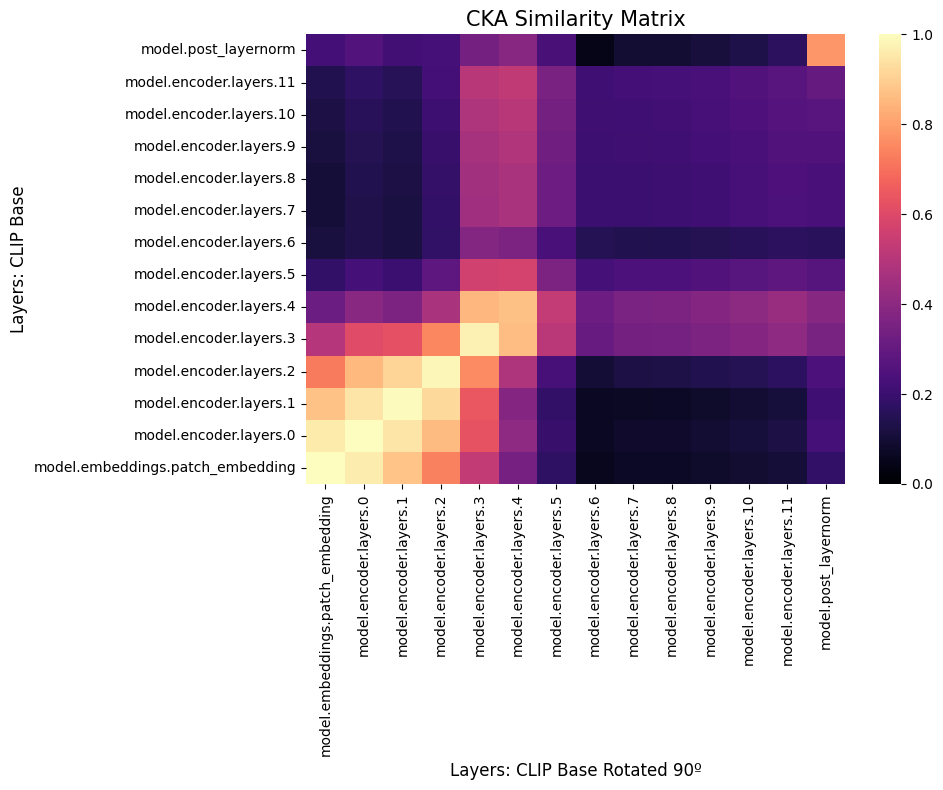

In [12]:
model_1_name = "CLIP Base"
model_2_name = "CLIP Base Rotated 90º"

results = load_from_pickle(model_1_name, model_2_name)

plot_cka_matrix(results)

In [13]:
clear_gpu_memory()

GPU memory cleared.


##### Rotate 180

In [ ]:
model_1_name = "CLIP Base"
model_2_name = "CLIP Base Rotated 180º"

clip_1 = CLIPModel.from_pretrained("openai/clip-vit-base-patch16").to(device)
clip_2 = CLIPModel.from_pretrained("openai/clip-vit-base-patch16").to(device)

model_1 = CLIPVisionWrapper(clip_1)
model_2 = CLIPVisionWrapper(clip_2)

cka = CKA(
    model_1,
    model_2,
    model1_name=model_1_name,
    model2_name=model_2_name,
    model1_layers=layers_to_compare,
    model2_layers=layers_to_compare,
    device=device,
)

loader_affine = get_affine_dataset(processor, rotation=(180, 180))
cka.compare(loader, loader_affine, NaN_fix=True)
results = cka.export()

save_to_pickle(results, model_1_name, model_2_name)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
| Comparing features |:   0%|                                                                     | 0/2 [00:00<?, ?it/s]

Forward ran
Forward ran


| Comparing features |:  50%|██████████████████████████████▌                              | 1/2 [00:01<00:01,  1.82s/it]

Forward ran
Forward ran


| Comparing features |: 100%|█████████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.10s/it]


In [ ]:
del clip_1
del clip_2
del model_1
del model_2
del cka
clear_gpu_memory()

GPU memory cleared.


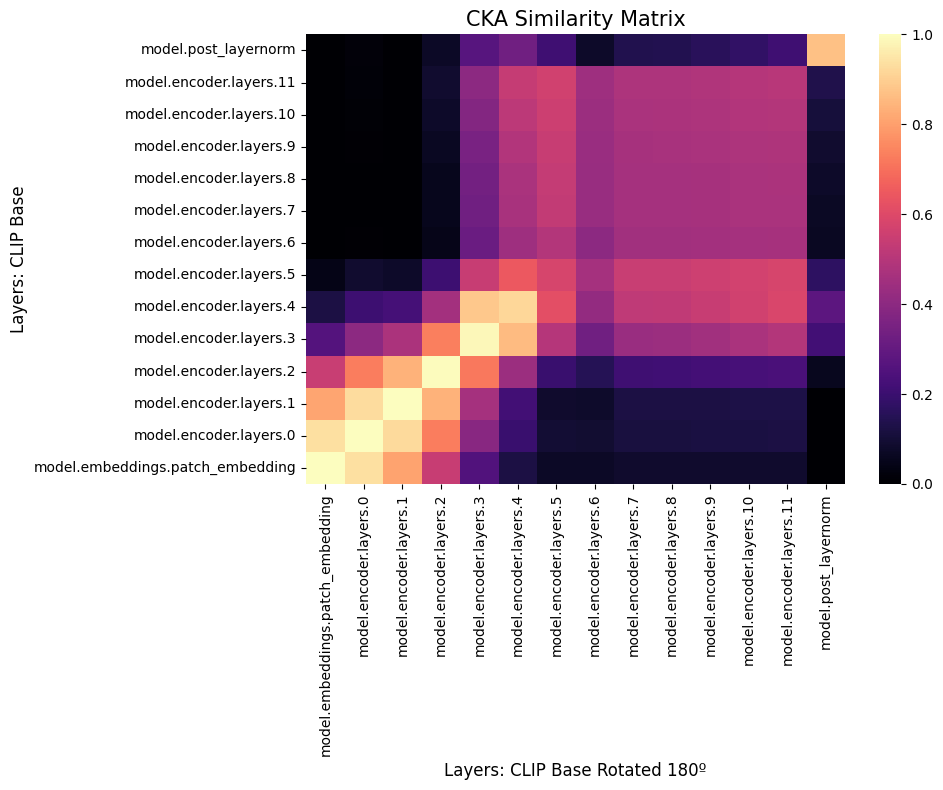

In [14]:
model_1_name = "CLIP Base"
model_2_name = "CLIP Base Rotated 180º"

results = load_from_pickle(model_1_name, model_2_name)

plot_cka_matrix(results)

In [15]:
clear_gpu_memory()

GPU memory cleared.


##### Scale x2

In [ ]:
model_1_name = "CLIP Base"
model_2_name = "CLIP Base Scale x2"

clip_1 = CLIPModel.from_pretrained("openai/clip-vit-base-patch16").to(device)
clip_2 = CLIPModel.from_pretrained("openai/clip-vit-base-patch16").to(device)

model_1 = CLIPVisionWrapper(clip_1)
model_2 = CLIPVisionWrapper(clip_2)

cka = CKA(
    model_1,
    model_2,
    model1_name=model_1_name,
    model2_name=model_2_name,
    model1_layers=layers_to_compare,
    model2_layers=layers_to_compare,
    device=device,
)

loader_affine = get_affine_dataset(processor, scale=(2.0, 2.0))
cka.compare(loader, loader_affine, NaN_fix=True)
results = cka.export()

save_to_pickle(results, model_1_name, model_2_name)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
| Comparing features |: 100%|█████████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.13s/it]


In [ ]:
del clip_1
del clip_2
del model_1
del model_2
del cka
clear_gpu_memory()

GPU memory cleared.


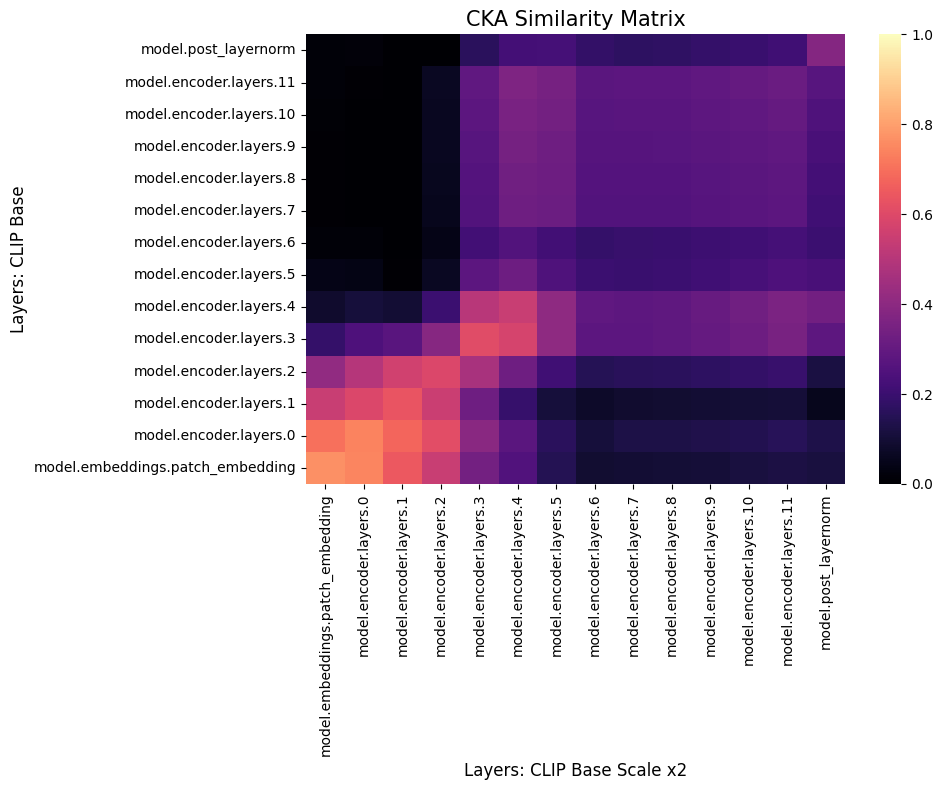

In [14]:
model_1_name = "CLIP Base"
model_2_name = "CLIP Base Scale x2"

results = load_from_pickle(model_1_name, model_2_name)

plot_cka_matrix(results)

In [ ]:
clear_gpu_memory()

GPU memory cleared.


##### Shear 50

In [ ]:
model_1_name = "CLIP Base"
model_2_name = "CLIP Base Shear 50"

clip_1 = CLIPModel.from_pretrained("openai/clip-vit-base-patch16").to(device)
clip_2 = CLIPModel.from_pretrained("openai/clip-vit-base-patch16").to(device)

model_1 = CLIPVisionWrapper(clip_1)
model_2 = CLIPVisionWrapper(clip_2)

cka = CKA(
    model_1,
    model_2,
    model1_name=model_1_name,
    model2_name=model_2_name,
    model1_layers=layers_to_compare,
    model2_layers=layers_to_compare,
    device=device,
)

loader_affine = get_affine_dataset(processor, shear=(50, 50))
cka.compare(loader, loader_affine, NaN_fix=True)
results = cka.export()

save_to_pickle(results, model_1_name, model_2_name)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
| Comparing features |: 100%|█████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.58it/s]


In [ ]:
del clip_1
del clip_2
del model_1
del model_2
del cka
clear_gpu_memory()

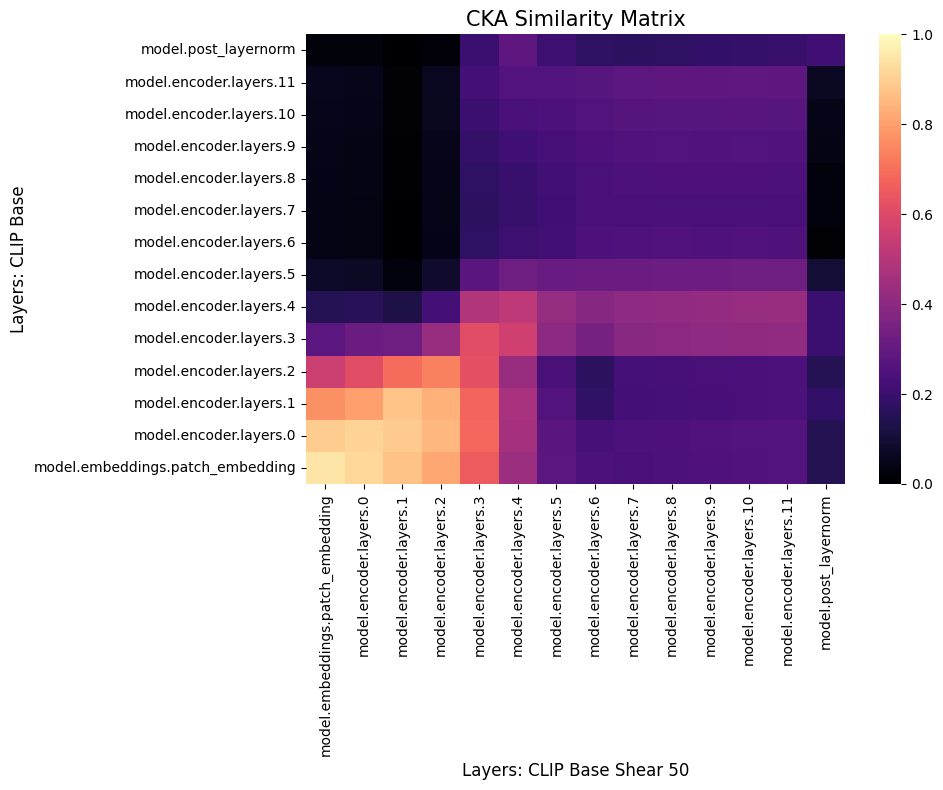

In [20]:
model_1_name = "CLIP Base"
model_2_name = "CLIP Base Shear 50"

results = load_from_pickle(model_1_name, model_2_name)

plot_cka_matrix(results)

In [21]:
clear_gpu_memory()

GPU memory cleared.


### SigLIP Base

In [8]:
class SigLIPVisionWrapper(torch.nn.Module):
    def __init__(self, siglip_model):
        super().__init__()
        self.model = siglip_model.vision_model

    def forward(self, x):
        out = self.model(pixel_values=x)
        return out.pooler_output

In [ ]:
from transformers import AutoModel, AutoProcessor

siglip = AutoModel.from_pretrained("google/siglip-base-patch16-224")
model = SigLIPVisionWrapper(siglip)
processor = AutoProcessor.from_pretrained("google/siglip-base-patch16-224")
loader = get_affine_dataset(processor)

available_layers = [name for name, _ in model.named_modules()]
# print("Available layers in the model:")
# for layer in available_layers:
#     print(layer)

del siglip
del model
clear_gpu_memory()

layers_to_compare = ["model.embeddings.patch_embedding"]
layers_to_compare += [f"model.encoder.layers.{i}" for i in range(12)]
layers_to_compare += ["model.post_layernorm"]
layers_to_compare

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

GPU memory cleared.


['model.embeddings.patch_embedding',
 'model.encoder.layers.0',
 'model.encoder.layers.1',
 'model.encoder.layers.2',
 'model.encoder.layers.3',
 'model.encoder.layers.4',
 'model.encoder.layers.5',
 'model.encoder.layers.6',
 'model.encoder.layers.7',
 'model.encoder.layers.8',
 'model.encoder.layers.9',
 'model.encoder.layers.10',
 'model.encoder.layers.11',
 'model.post_layernorm']

##### Baseline

In [20]:
model_1_name = "SigLIP Base"
model_2_name = "SigLIP Base"

siglip_1 = AutoModel.from_pretrained("google/siglip-base-patch16-224").to(device)
siglip_2 = AutoModel.from_pretrained("google/siglip-base-patch16-224").to(device)

model_1 = SigLIPVisionWrapper(siglip_1)
model_2 = SigLIPVisionWrapper(siglip_2)

cka = CKA(
    model_1,
    model_2,
    model1_name=model_1_name,
    model2_name=model_2_name,
    model1_layers=layers_to_compare,
    model2_layers=layers_to_compare,
    device=device,
)

loader_affine = get_affine_dataset(processor)
cka.compare(loader, loader_affine, NaN_fix=True)
results = cka.export()

save_to_pickle(results, model_1_name, model_2_name)

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

/dtu/3d-imaging-center/courses/02518/groups/members/Eric_s257372/ADLCV_Project/.venv/lib/python3.11/site-packages/torch_cka/cka.py:53: UserWarning: Both model have identical names - SigLIP Base. It may cause confusion when interpreting the results. Consider giving unique names to the models :)
  warn(
| Comparing features |: 100%|█████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.71it/s]


In [21]:
del siglip_1
del siglip_2
del model_1
del model_2
del cka
clear_gpu_memory()

GPU memory cleared.


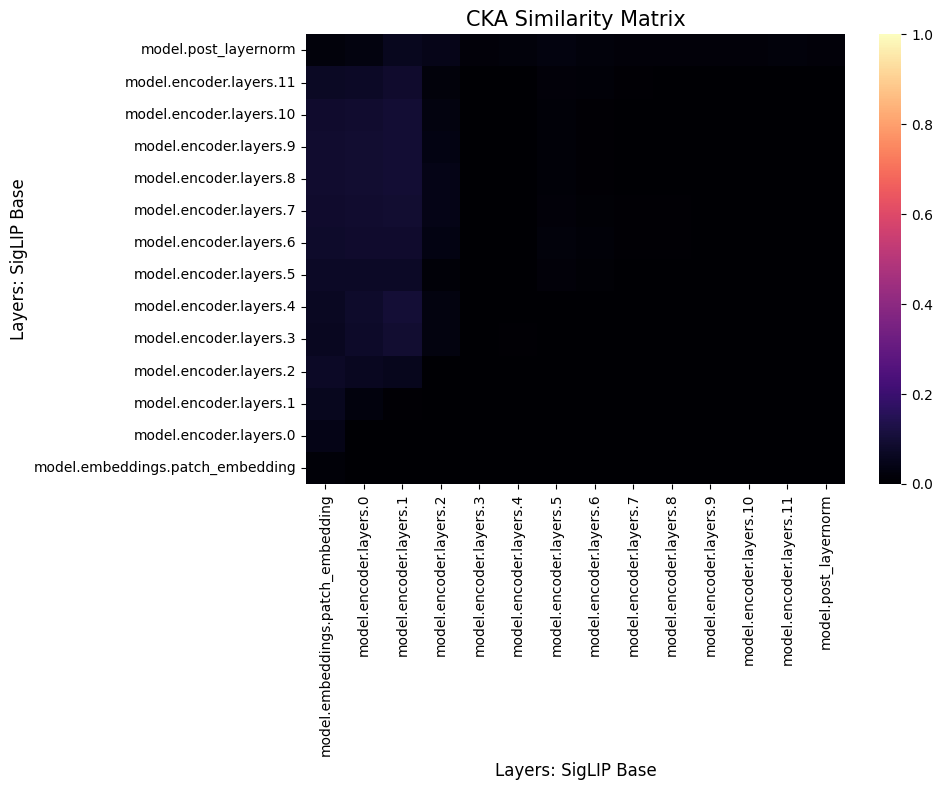

In [22]:
model_1_name = "SigLIP Base"
model_2_name = "SigLIP Base"

results = load_from_pickle(model_1_name, model_2_name)

plot_cka_matrix(results)

In [23]:
clear_gpu_memory()

GPU memory cleared.
